<a href="https://colab.research.google.com/github/HepsibaMark/Alfido-Tech-Internship/blob/main/Task2_Sales_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('superstore_final_dataset (1).csv', encoding='latin1')
df.head()
df.info()
df['Order_Date']=pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date']=pd.to_datetime(df['Ship_Date'],dayfirst=True)
print(df.duplicated().sum())
df=df.drop_duplicates()
print((df['Ship_Date']<df['Order_Date']).sum())
df.isnull().sum()
df.dtypes
df['Order_Year']=df['Order_Date'].dt.year
df['Order_Month']=df['Order_Date'].dt.month
df['Order_YearMonth'] = df['Order_Date'].dt.to_period('M').astype(str)
df[['Order_Date','Order_Year','Order_Month','Order_YearMonth']].head()
order_level=df.groupby("Order_ID").agg(
    Order_Revenue=('Sales','sum'),
    Line_Items=('Sales','count')
    ).reset_index()
total_revenue = df['Sales'].sum()
total_orders=df['Order_ID'].nunique()
aov=order_level['Order_Revenue'].mean()
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total_Orders: {total_orders:,.2f}")
print(f"AOV: ${aov:,.2f}")
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [28]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [29]:
bottom_products=df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=True).head(10)
print(bottom_products)

Product_Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Name: Sales, dtype: float64


Order_Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64


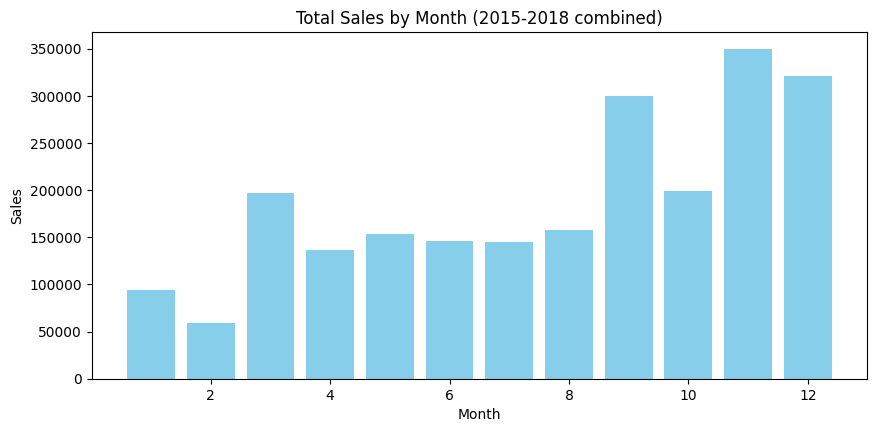

In [34]:
import matplotlib.pyplot as plt
monthly_sales=df.groupby('Order_Month')['Sales'].sum()
print(monthly_sales)
plt.figure(figsize=(10,4.5))
plt.bar(monthly_sales.index,monthly_sales.values,color='skyblue')
plt.title('Total Sales by Month (2015-2018 combined)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

## Key Findings
# Superstore Sales Performance Analysis
**Alfido Tech Internship — Task 2, Level [whichever level this is]**

Dataset: Sample Superstore Sales (Kaggle), 2015–2018

- Revenue is strongest in November (\$350K), December (\$320K), and September (\$300K) — clear year-end seasonality.
- South region generates only \$389K vs West's \$710K — a reach/awareness gap, not a pricing issue.
- Top products (copiers, binding machines) earn \$17K–\$61K each; bottom products (paper clips, envelopes) earn under \$10 each — a long tail of low-impact SKUs.
- Technology has fewer transactions but higher revenue per sale; Office Supplies has more transactions but lower value per sale.
- AOV is $459.48 across 4,922 orders — room to grow revenue per order from existing customers.

## Tactical Recommendations

1. **Plan a Q4-focused sales push.** Concentrate promotions and inventory stock-up around Sep–Dec instead of spreading budget evenly across the year.

2. **Run a targeted growth campaign in the South region.** Comparable order patterns but half the revenue of West points to a reach gap — invest in region-specific marketing or added sales coverage.

3. **Rationalize the long tail of low-revenue products.** Bundle tiny-ticket accessories into multi-packs or checkout add-ons rather than standalone listings.

4. **Cross-sell Technology with Office Supplies.** Bundle high-frequency, low-value Office Supplies purchases with higher-value Technology items to lift AOV.

5. **Build a repeat-customer upsell program.** Introduce loyalty incentives or upgrade prompts to grow revenue per order from the existing customer base rather than only chasing new acquisition.

**Note on scope:** This dataset contains Sales only — no Profit, Quantity, Discount, or conversion/funnel data — so this analysis is revenue-based, and recommendations are directional pending actual margin data.